In [1]:
import  pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import lasso_path
import os
import matplotlib.pyplot as plt


path =  r'C:\Users\peter\OneDrive\Desktop\UST-AI\Machine_Learning\WD'
os.chdir(path)
print(os.getcwd())

C:\Users\peter\OneDrive\Desktop\UST-AI\Machine_Learning\WD


In [2]:
#Read in dataset
DF = pd.read_csv("computer_prices_all .csv")
DF.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
#create list of categorical columns but going to drop model, form factor, cpu_model  because they are too specific and have 
# too many unique values. When orginally created dummies with these, returned 126097 observations. Cut those 3 columns returned 35 
# observations which is more manageable for modeling.
categorical_cols = [
    'device_type', 
    'brand',  
    'os', 
    'cpu_brand',  
    'gpu_brand', 
    'storage_type',
    'display_type', 
    'resolution',
    'wifi',
    'bluetooth'
]

In [4]:
#create list of ordinal columns
ordinal_cols = ['cpu_tier', 'gpu_tier']

In [5]:
#create list of numeric columns
numeric_cols = [
    'release_year', 
    'cpu_cores', 
    'cpu_threads',
    'cpu_base_ghz', 
    'cpu_boost_ghz', 
    'vram_gb', 'ram_gb',
    'storage_gb', 
    'storage_drive_count', 
    'display_size_in',
    'refresh_hz', 
    'battery_wh', 
    'charger_watts', 
    'psu_watts',
    'weight_kg', 
    'warranty_months'
]

In [6]:
#create target variable
y = DF['price']

In [7]:
#create raw numeric dataframe
numeric_df = DF[numeric_cols]

In [8]:
#standardize numeric columns
scaler = StandardScaler()
numeric_standarized = scaler.fit_transform(DF[numeric_cols])
numeric_standarized_df = pd.DataFrame(numeric_standarized, columns=numeric_cols)

In [9]:
numeric_standarized_df.head()

,release_year,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,warranty_months
0,-0.158386,0.294259,0.476139,0.620265,0.767636,-0.038382,-0.743089,0.155073,-0.658463,1.024413,-0.195487,-1.165738,-0.977526,1.346209,1.759106,1.348695
1,-0.158386,0.294259,0.476139,0.025794,0.196244,0.970469,0.761495,-0.506220,-0.658463,-0.615043,-0.195487,0.395513,0.933463,-0.768346,-0.592380,-0.996922
2,0.828903,-0.498752,-0.347044,0.025794,0.196244,-0.542807,-0.993852,-0.506220,0.595800,1.769620,0.497331,-1.165738,-0.977526,1.628149,0.710505,0.175886
3,0.828903,-0.895258,-0.758635,0.025794,0.196244,-0.038382,-0.743089,-0.506220,0.595800,1.024413,0.497331,-1.165738,-0.977526,1.064268,0.448355,1.348695
4,0.828903,1.087269,1.299322,0.620265,1.053332,1.474895,1.764550,-0.836867,-0.658463,-0.674659,-0.195487,1.064621,0.455716,-0.768346,-0.731320,-0.996922


In [10]:
#create dummy variables for categorical columns
DF_dummies = pd.get_dummies(DF[categorical_cols], drop_first=True)

In [11]:
DF_dummies.head()

,bluetooth,device_type_Laptop,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_Lenovo,brand_MSI,brand_Razer,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
0,5.1,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,5.3,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,5.0,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
3,5.2,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,5.2,True,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


In [12]:
#create ordinal df and map cpu and gpu tiers to numeric values
DF_ordinal = DF[ordinal_cols].copy()

In [13]:
DF_ordinal.head()

,cpu_tier,gpu_tier
0,3,2
1,4,4
2,2,1
3,2,2
4,5,5


In [14]:
#create boolean mask to remove outliers from numeric dataframe. Using 3 standard deviations from the mean as the cutoff for outliers.
z = np.abs(numeric_standarized_df)
mask = (z < 3).all(axis=1)

In [15]:
#apply mastk to all datasets even if they are not effected to ensure rows line up for modeling
# Apply mask to numeric scaled data
numeric_df = numeric_df[mask]
DF_ordinal = DF_ordinal[mask]
DF_dummies = DF_dummies[mask]
y = y[mask]

In [16]:
#reset index on all datasets after removing outliers to ensure they are aligned for modeling
numeric_df = numeric_df.reset_index(drop=True)
DF_ordinal = DF_ordinal.reset_index(drop=True)
DF_dummies = DF_dummies.reset_index(drop=True)
y = y.reset_index(drop=True)

In [17]:
#standarize numeric columns again after removing outliers to ensure they are on the same scale for modeling. 
# This is because removing outliers can change the mean and standard deviation of the data, which can affect the scaling.
scaler = StandardScaler()
numeric_restandardized_df = pd.DataFrame(
    scaler.fit_transform(numeric_df),  
    columns=numeric_df.columns)

In [18]:
#build x dataset by concatenating numeric, ordinal, and dummy dataframes
X = pd.concat([numeric_restandardized_df, DF_ordinal, DF_dummies], axis=1)
X

,release_year,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
0,-0.157538,0.385853,0.567085,0.711016,0.858743,-0.019460,-0.733531,0.399661,-0.666142,1.106095,...,False,False,True,False,False,False,False,True,False,False
1,-0.157538,0.385853,0.567085,0.098582,0.271308,1.014037,0.854598,-0.541172,-0.666142,-0.562389,...,False,False,False,False,False,False,False,True,False,False
2,0.829206,-0.480267,-0.319695,0.098582,0.271308,-0.536209,-0.998219,-0.541172,0.936453,1.864497,...,False,False,False,False,False,True,False,True,False,False
3,0.829206,-0.913326,-0.763085,0.098582,0.271308,-0.019460,-0.733531,-0.541172,0.936453,1.106095,...,False,False,False,False,False,True,False,True,False,False
4,0.829206,1.251973,1.453864,0.711016,1.152461,1.530785,1.913351,-1.011589,-0.666142,-0.623062,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87888,0.335834,0.385853,0.567085,0.711016,0.858743,-0.019460,-0.733531,0.399661,2.539048,0.651054,...,False,False,False,False,False,True,False,False,False,False
87889,0.335834,0.385853,0.567085,0.098582,0.565025,0.497288,-0.204154,2.281327,-0.666142,-0.865750,...,False,False,False,False,False,False,False,True,False,False
87890,-2.131026,-0.480267,-0.319695,-1.126284,-0.903563,-0.536209,-0.998219,0.399661,-0.666142,-0.865750,...,False,False,False,True,False,False,False,True,False,False
87891,-1.144282,-0.913326,-0.984780,-1.126284,-0.903563,-0.019460,-0.733531,0.399661,-0.666142,-0.865750,...,False,False,False,True,False,False,False,True,False,False


In [19]:
# Building Model
# Split dataset into training and testing portion
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20 ,random_state = 1234)

# diagnose data types before fitting
print("Overall dtypes:")
print(X_train.dtypes.value_counts())
non_numeric = [c for c in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[c])]
print("Non-numeric predictors:", non_numeric)
print("Sample values from non-numeric cols:")
for c in non_numeric:
    print(c, X_train[c].unique()[:10])
print("y_train dtype:", y_train.dtype)

# Create an instance of our model
reg = LinearRegression()
# Fit the model
reg.fit(X_train, y_train)
# Get multiple predict
y_pred = reg.predict(X_test)

Overall dtypes:
bool       34
float64    17
int64       2
Name: count, dtype: int64
Non-numeric predictors: []
Sample values from non-numeric cols:
y_train dtype: float64


In [20]:
# Evaluate the model
print("Intercept:", reg.intercept_)
print("Coefficients:")
for name,coef in zip(X.columns, reg.coef_):
    print(f"  {name:25s} {coef:.4f}")

Intercept: 352.43492611922375
Coefficients:
  release_year              52.8239
  cpu_cores                 114.0832
  cpu_threads               -107.2280
  cpu_base_ghz              -95.5024
  cpu_boost_ghz             -0.7483
  vram_gb                   14.2636
  ram_gb                    59.2892
  storage_gb                50.9097
  storage_drive_count       -0.6715
  display_size_in           -0.1353
  refresh_hz                36.7111
  battery_wh                -0.7122
  charger_watts             8.1477
  psu_watts                 16.8399
  weight_kg                 -2.6928
  warranty_months           -0.7894
  cpu_tier                  162.2371
  gpu_tier                  170.2997
  bluetooth                 3.9548
  device_type_Laptop        159.0882
  brand_Acer                -87.5996
  brand_Apple               110.5196
  brand_Dell                35.6731
  brand_Gigabyte            3.5178
  brand_HP                  -0.0700
  brand_Lenovo              19.7394
  brand_MSI   

In [21]:
#Evalute the model more rigorously by calculating MSE and R² on hold‑out set and comparing predictions with actuals.
mse = mean_squared_error(y_test, y_pred)
r2  = reg.score(X_test, y_test)          # R² on hold‑out
print(f"\nMSE (test) = {mse:.3f}")
print(f"R²  (test) = {r2:.3f}")

# 2. compare predictions with actuals
results = pd.DataFrame({
    "actual"   : y_test,
    "predicted": y_pred
})
display(results.head())     


MSE (test) = 47168.317
R²  (test) = 0.851


,actual,predicted
51667,2295.99,2109.982105
24109,1102.99,1238.307419
42983,1857.99,1923.745640
16367,1352.99,1421.712497
42575,1815.99,2015.639795


In [22]:
# do regulrization with Lasso Regression with 10 fold cross validation
lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=1234)) 
lasso_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [23]:
#evaluate results of lasso regression by looking at coefficients and lambda value
lasso = lasso_model.named_steps['lassocv']
coef =lasso.coef_
features = X.columns
results = pd.DataFrame({
    "feature": features,
    "theta": coef
})

print(results)
print("\nLambda:", lasso.alpha_)


                  feature       theta
0            release_year   52.443868
1               cpu_cores   92.918591
2             cpu_threads  -83.606560
3            cpu_base_ghz    0.000000
4           cpu_boost_ghz    0.000000
5                 vram_gb   10.831643
6                  ram_gb   58.891500
7              storage_gb   49.730970
8     storage_drive_count   -0.408610
9         display_size_in   -0.000000
10             refresh_hz   35.680398
11             battery_wh    0.000000
12          charger_watts    7.398230
13              psu_watts    7.417022
14              weight_kg   -1.534092
15        warranty_months   -0.375115
16               cpu_tier  136.084501
17               gpu_tier  244.854817
18              bluetooth    0.128645
19     device_type_Laptop  125.563343
20             brand_Acer  -26.765268
21            brand_Apple   67.056288
22             brand_Dell   11.104435
23         brand_Gigabyte   -0.000000
24               brand_HP   -0.405387
25          

In [24]:
#sourt results by absolute value of coefficients to see which features are most important in the model
results_sorted = results.reindex(results.theta.abs().sort_values(ascending=False).index)
results_sorted


,feature,theta
17,gpu_tier,244.854817
16,cpu_tier,136.084501
31,os_macOS,132.344495
19,device_type_Laptop,125.563343
42,display_type_OLED,104.123902
49,resolution_3840x2160,100.782074
1,cpu_cores,92.918591
2,cpu_threads,-83.606560
21,brand_Apple,67.056288
41,display_type_Mini-LED,60.267641


In [25]:
# create lasso predictions
y_pred1 = lasso_model.predict(X_test)

In [29]:
#Evalute the model after lasso by calculating MSE and R² on hold‑out set and comparing predictions with actuals.
mse1 = mean_squared_error(y_test, y_pred1)
r21  = reg.score(X_test, y_test)          # R² on hold‑out
print(f"\nMSE (test) = {mse1:.3f}")
print(f"R²  (test) = {r21:.3f}")

# 2. compare predictions with actuals
results1 = pd.DataFrame({
    "actual"   : y_test,
    "predicted": y_pred1
})
display(results1)


MSE (test) = 47119.105
R²  (test) = 0.851


,actual,predicted
51667,2295.99,2111.118383
24109,1102.99,1241.280842
42983,1857.99,1921.608120
16367,1352.99,1422.049689
42575,1815.99,2012.694343
...,...,...
33933,1595.99,1730.973470
23701,1781.99,1595.058949
26434,2409.99,2585.231102
32767,2432.99,2064.500760


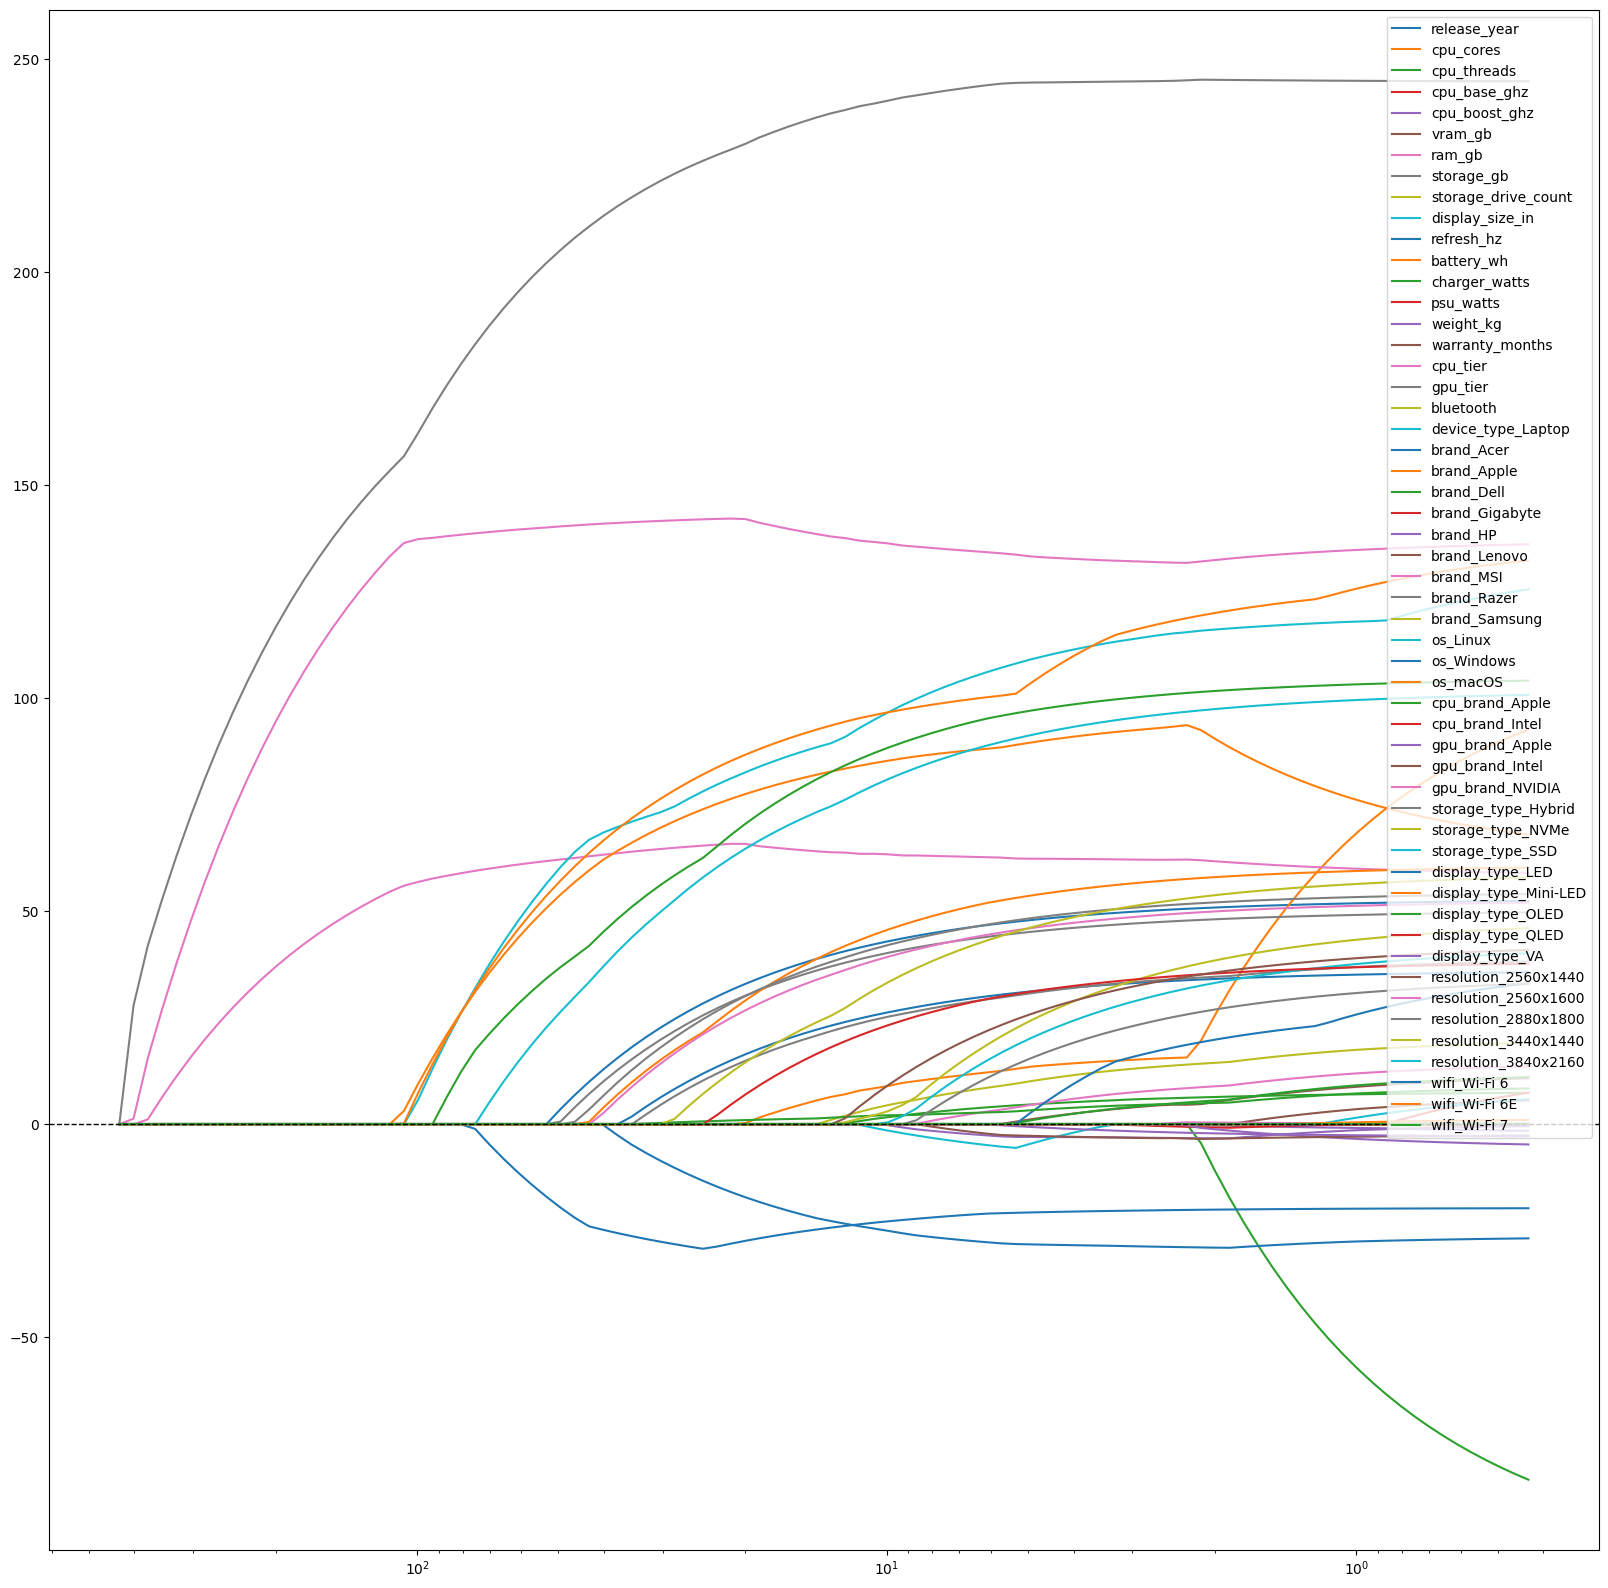

In [27]:
#plot lasso path to visualize how coefficients change with different lambda values
x_plot = StandardScaler().fit_transform(X)
alphas, coefs, _ = lasso_path(x_plot, y, alphas=None)
plt.figure(figsize=(20, 20))
for i in range(coefs.shape[0]):
    plt.plot(alphas, coefs[i], label=X.columns[i])

plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend(loc='best')
plt.axhline(0, color='black', linewidth=1, linestyle='--')


Text(0.5, 1.0, 'Residual Plot')

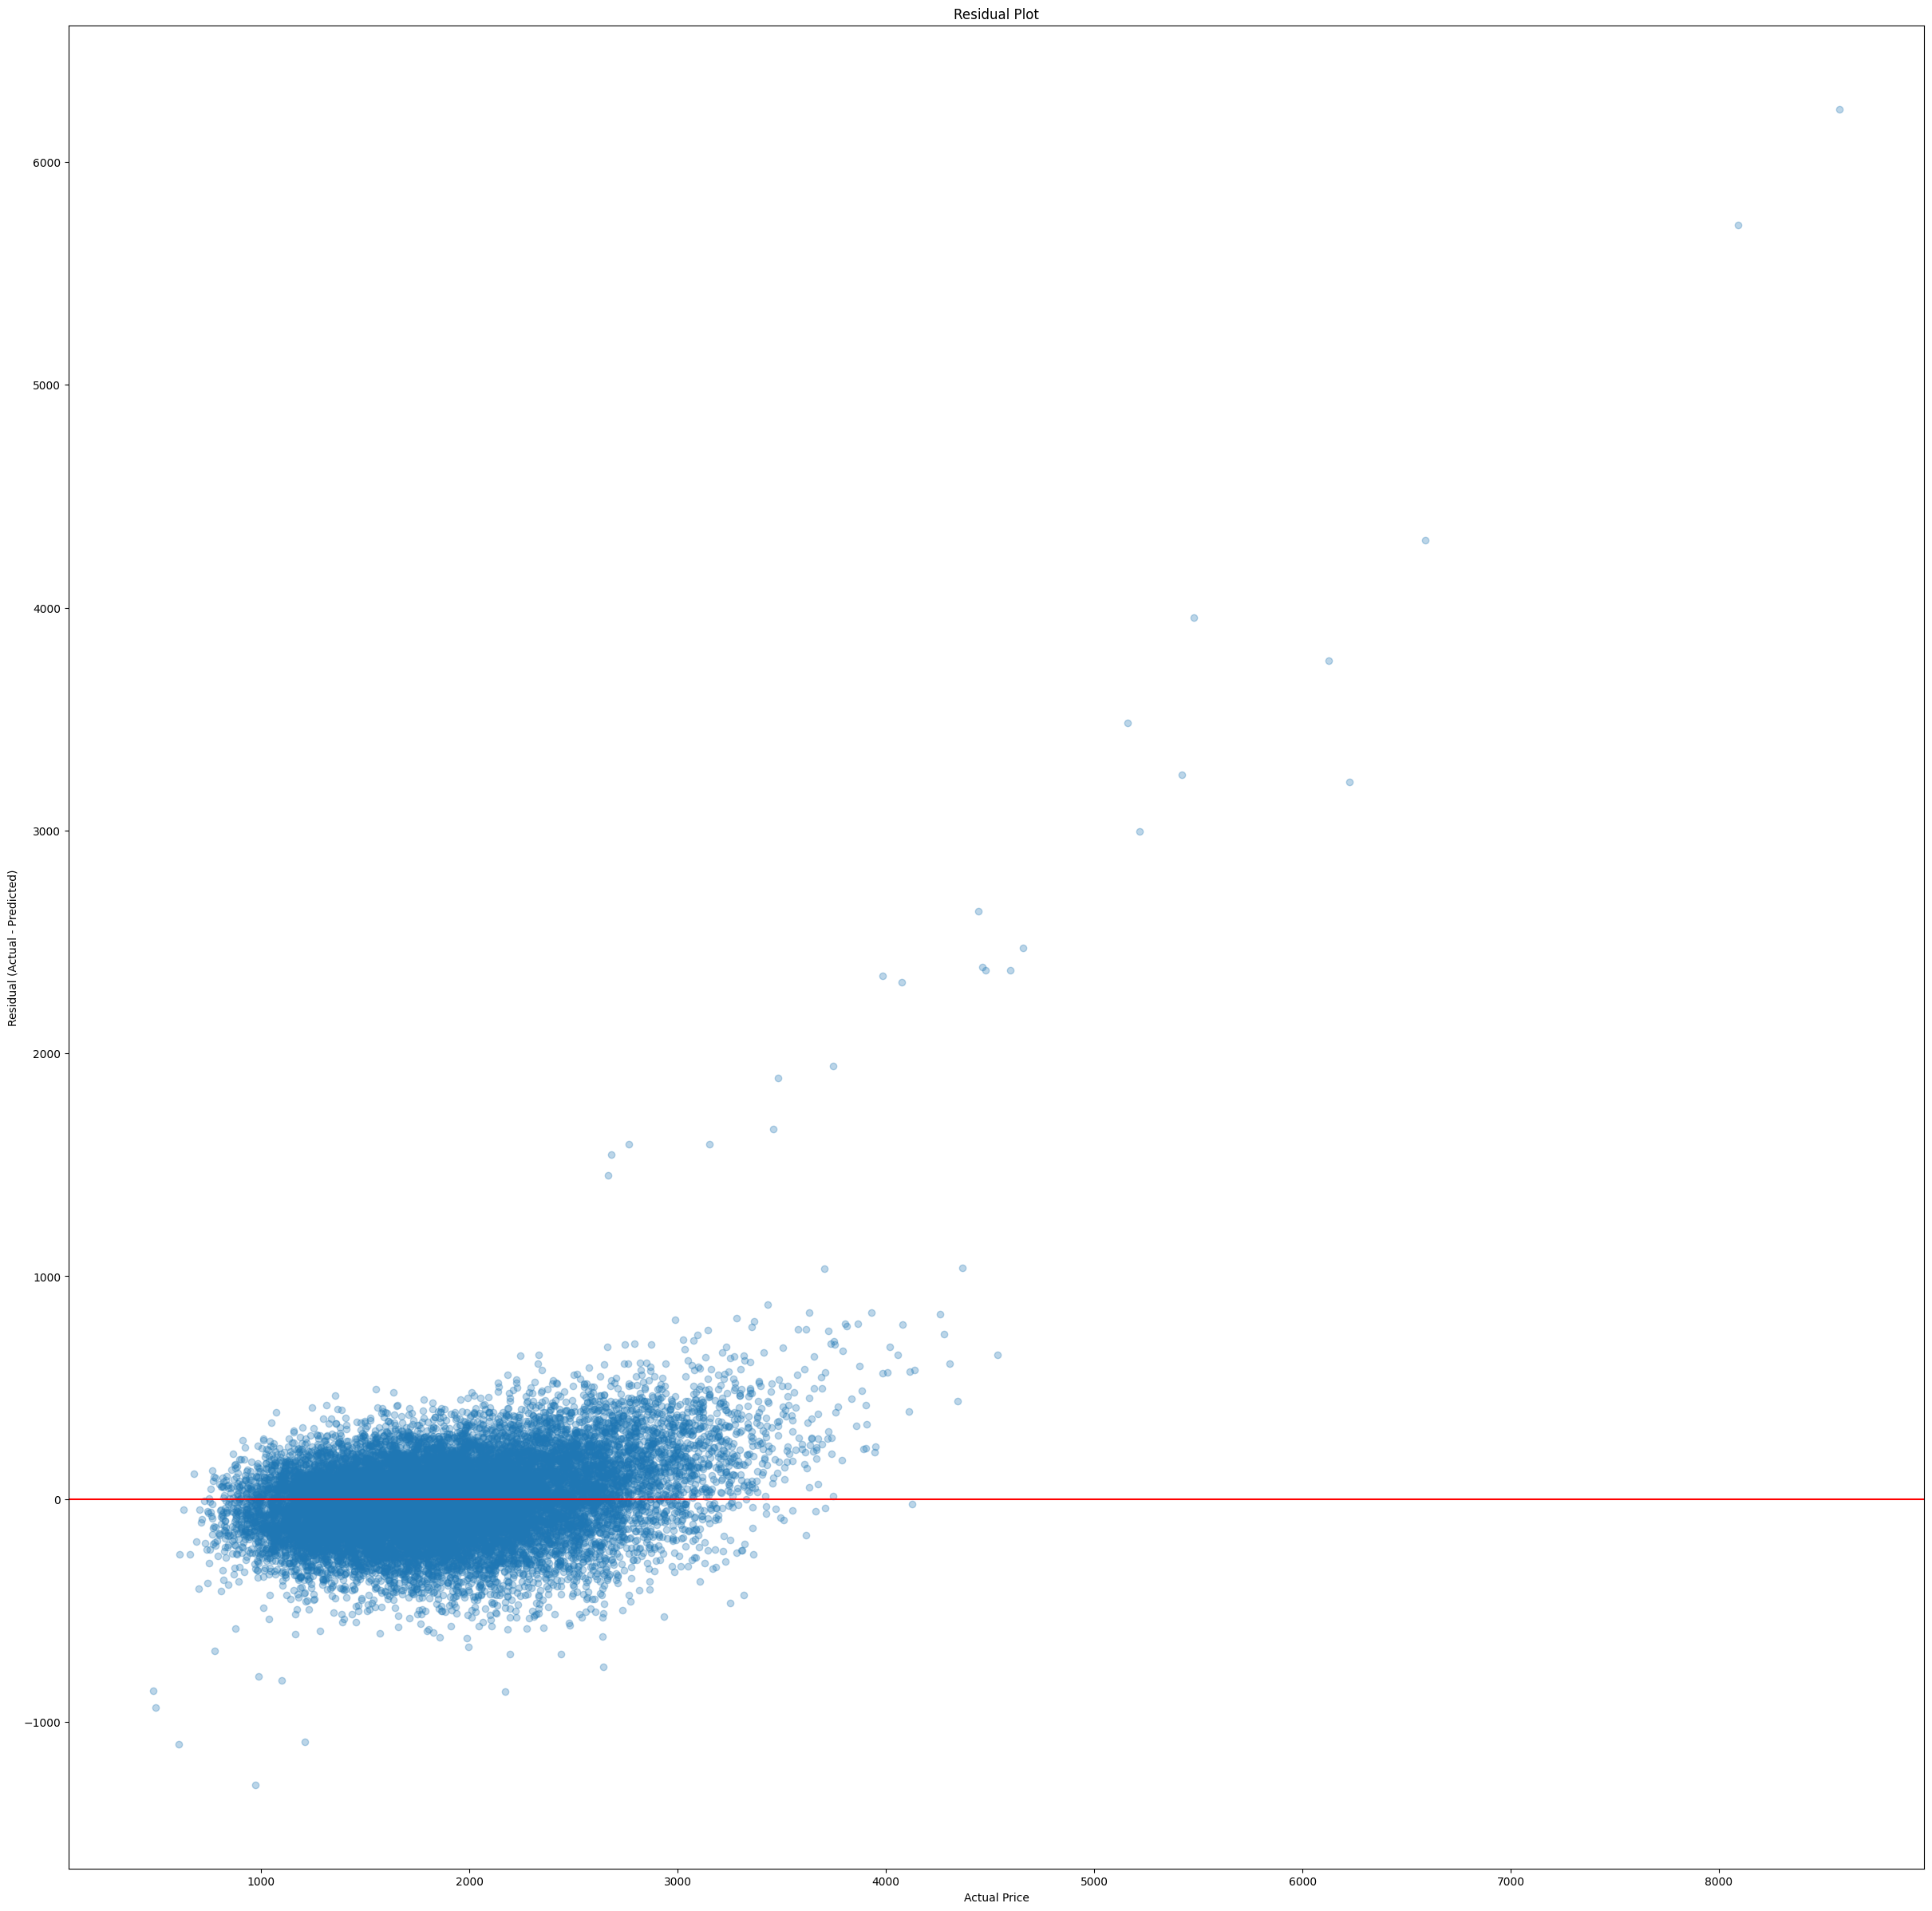

In [28]:
#plotting resideuals 
plt.figure(figsize=(30, 30))   # set figure size here

plt.scatter(y_test, y_test - y_pred, alpha=0.3)

plt.axhline(0, color='red')
plt.xlabel("Actual Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")